In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [30]:
df=pd.read_csv('netflix1.csv')
df.head(20)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [5]:
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'TV-PG', 'TV-14', 'TV-Y7', 'TV-Y', 'PG', 'TV-G',
       'R', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

## what we can visualize
1)number of films or movies based on certain time period 

2)from which countries top 5 countries with highest shows and movies 

3)how many types in listed_in 

4)movies releases on certain period like after 2022 or 2023 or 2024 like that

5)which year highest number of movies got released

6)top 5 highest duration film

7)top highest rating films 

8)top highest rating shows

(array([2014., 2015., 2016., 2017., 2018., 2019., 2020., 2021., 2022.]),
 [Text(2014.0, 0, '2014'),
  Text(2015.0, 0, '2015'),
  Text(2016.0, 0, '2016'),
  Text(2017.0, 0, '2017'),
  Text(2018.0, 0, '2018'),
  Text(2019.0, 0, '2019'),
  Text(2020.0, 0, '2020'),
  Text(2021.0, 0, '2021'),
  Text(2022.0, 0, '2022')])

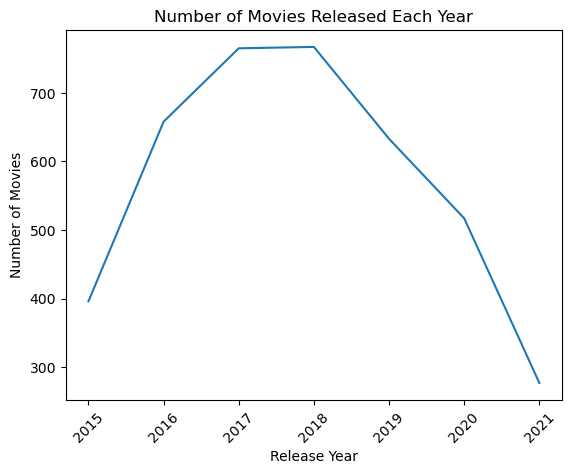

In [13]:
movies=df[(df['type']=='Movie') & (df['release_year'] >= 2015)]
movie_count=(movies.groupby('release_year').size().reset_index(name='count'))

sns.lineplot(data=movie_count,x='release_year',y='count')
plt.title('Number of Movies Released Each Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)

Text(0, 0.5, 'Number of TV Shows')

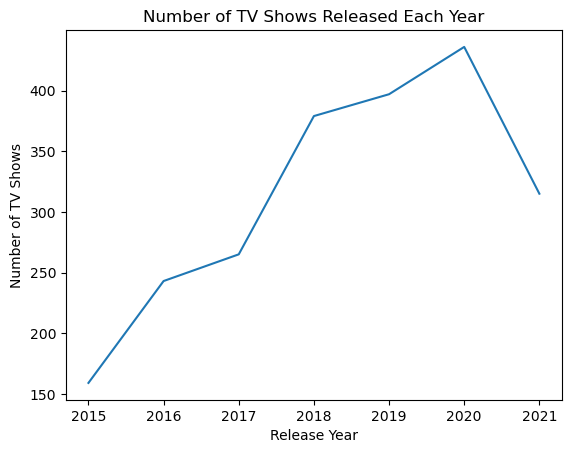

In [14]:
shows=df[(df['type']=='TV Show') & (df['release_year'] >= 2015)]
show_count=(shows.groupby('release_year').size().reset_index(name='count'))
sns.lineplot(data=show_count,x='release_year',y='count')
plt.title('Number of TV Shows Released Each Year')
plt.xlabel('Release Year')
plt.ylabel('Number of TV Shows')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'United States'),
  Text(1, 0, 'India'),
  Text(2, 0, 'United Kingdom'),
  Text(3, 0, 'Pakistan'),
  Text(4, 0, 'Not Given')])

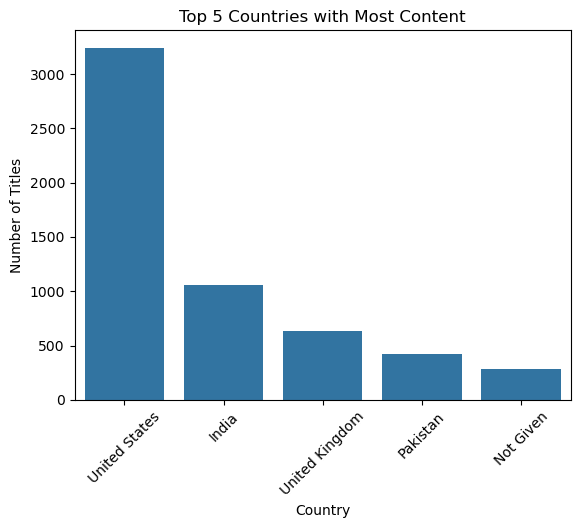

In [31]:
country_count=df['country'].value_counts().head(5).reset_index()
sns.barplot(data=country_count,x='country',y='count')
plt.title('Top 5 Countries with Most Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'International Movies'),
  Text(1, 0, 'Dramas'),
  Text(2, 0, 'Comedies'),
  Text(3, 0, 'International TV Shows'),
  Text(4, 0, 'Documentaries')])

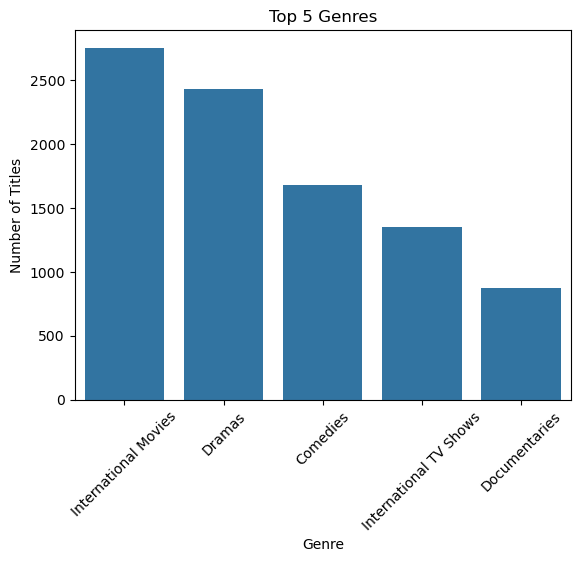

In [ ]:
genre_count=df['listed_in'].str.split(', ').explode().value_counts().head().reset_index()
sns.barplot(data=genre_count,x='listed_in',y='count')
plt.title('Top 5 Genres') 
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'TV-MA'),
  Text(1, 0, 'TV-14'),
  Text(2, 0, 'TV-PG'),
  Text(3, 0, 'R'),
  Text(4, 0, 'PG-13'),
  Text(5, 0, 'TV-Y7'),
  Text(6, 0, 'TV-Y'),
  Text(7, 0, 'PG'),
  Text(8, 0, 'TV-G'),
  Text(9, 0, 'NR'),
  Text(10, 0, 'G'),
  Text(11, 0, 'TV-Y7-FV'),
  Text(12, 0, 'NC-17'),
  Text(13, 0, 'UR')])

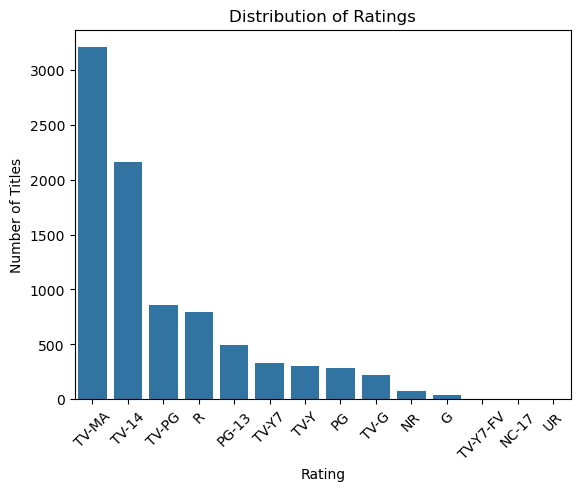

In [19]:
rating_count=df['rating'].value_counts().reset_index()
sns.barplot(data=rating_count,x='rating',y='count')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

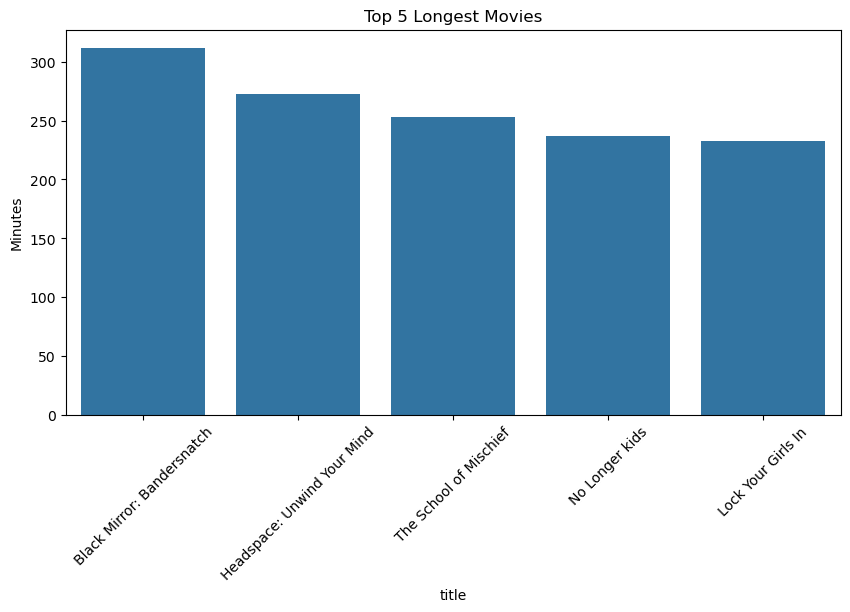

In [21]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_num'] = (movies['duration'].str.extract(r'(\d+)').astype(float))
top5 = (movies.nlargest(5, 'duration_num'))
plt.figure(figsize=(10,5))
sns.barplot(data=top5,x='title',y='duration_num')
plt.xticks(rotation=45)
plt.title("Top 5 Longest Movies")
plt.ylabel("Minutes")
plt.show()

In [29]:
print(df['country'].head(20))

0      United States
1             France
2      United States
3             Brazil
4      United States
5     United Kingdom
6      United States
7              India
8            Germany
9              India
10             India
11             India
12          Pakistan
13     United States
14     United States
15     United States
16     United States
17          Pakistan
18          Pakistan
19     United States
Name: country, dtype: object


In [28]:
country=df["country"]
country.head()
country.isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
8785    False
8786    False
8787    False
8788    False
8789    False
Name: country, Length: 8790, dtype: bool

In [26]:
country = df['country'].dropna()
country.head()
country.isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
8785    False
8786    False
8787    False
8788    False
8789    False
Name: country, Length: 8790, dtype: bool

In [ ]:
country = country.str.split(', ')
country.head()

0    [United States]
1           [France]
2    [United States]
3           [Brazil]
4    [United States]
Name: country, dtype: object

In [32]:
movies.groupby('release_year').size()

release_year
1942      2
1943      3
1944      3
1945      3
1946      1
       ... 
2017    765
2018    767
2019    633
2020    517
2021    277
Length: 73, dtype: int64

In [37]:
movies.groupby('release_year').size().reset_index()

,release_year,0
0,1942,2
1,1943,3
2,1944,3
3,1945,3
4,1946,1
...,...,...
68,2017,765
69,2018,767
70,2019,633
71,2020,517


In [36]:
movies.groupby('release_year').size().reset_index(name='count')

,release_year,count
0,1942,2
1,1943,3
2,1944,3
3,1945,3
4,1946,1
...,...,...
68,2017,765
69,2018,767
70,2019,633
71,2020,517
